$$
\mathcal X_- = \mathcal X[:,:,0:T-1],
\qquad
\mathcal X_+ = \mathcal X[:,:,1:T]
$$

$$
\mathcal X_- = \mathcal U \star \mathcal S \star \mathcal V^*
$$

$$
\mathcal U_r = \mathcal U[:,1\!:\!r,:],
\qquad
\mathcal S_r = \mathcal S[1\!:\!r,1\!:\!r,:],
\qquad
\mathcal V_r = \mathcal V[:,1\!:\!r,:]
$$

$$
\widetilde{\mathcal A}
= \mathcal U_r^* \star \mathcal X_+ \star \mathcal V_r \star \mathcal S_r^{\dagger}
$$

$$
\widetilde{\mathcal A} \star \mathcal W = \mathcal W \star \mathcal D
$$

$$
\Phi = \mathcal X_+ \star \mathcal V_r \star \mathcal S_r^{\dagger} \star \mathcal W
$$

$$
\widehat{\mathcal B}^{(\ell)} = \bigl(\widehat{\Phi}^{(\ell)}\bigr)^{\dagger} \widehat{X}_-^{(\ell)}
$$

$$
\widehat{X}_+^{(\ell)} = \widehat{\Phi}^{(\ell)} \widehat{D}^{(\ell)} \widehat{B}^{(\ell)},
\qquad \ell = 1,\dots,k
$$

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tdmd import FFTTransform, star_prod, tdmd, truncated_tsvd

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def make_plasma(nx=100, ny=100, nt=100):
    x = jnp.linspace(-1.0, 1.0, nx)
    y = jnp.linspace(-1.0, 1.0, ny)
    t = jnp.linspace(0.0, 4.0 * jnp.pi, nt)
    X, Y, T = jnp.meshgrid(x, y, t, indexing="ij")

    Xf = 5.0 * X - 5.0
    Yf = 5.0 * Y - 5.0
    R = jnp.sqrt(Xf**2 + Yf**2)
    Theta = jnp.arctan2(Yf, Xf + 1.0e-6)

    Z = (
        7.0 * jnp.sin(1.7 * Xf + 0.9 * T)
        + 6.0 * jnp.cos(1.3 * Yf - 1.2 * T)
        + 5.0 * jnp.sin(0.9 * (Xf + Yf) + 0.7 * T)
        + 4.0 * jnp.cos(2.2 * R - 1.8 * T)
        + 3.0 * jnp.sin(3.0 * Theta + 0.6 * R - 1.1 * T)
        + 2.5 * jnp.cos(1.8 * (Xf - Yf) + 0.3 * R + 0.8 * T)
    )
    return Z, t


def split_shifted_tensor(sequence):
    return sequence[:, :, :-1], sequence[:, :, 1:]


def relative_error(target, approx):
    return float(jnp.linalg.norm(target - approx) / jnp.linalg.norm(target))


def draw_frame(ax, frame, title, cmap="magma"):
    image = ax.imshow(np.asarray(jnp.real(frame)), origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return image


def reconstruct_tdmd_shift(x_minus, modes, eigen_tensor, transform):
    phi_hat = transform.to_slices(modes)
    d_hat = transform.to_slices(eigen_tensor)
    x_hat = transform.to_slices(x_minus)

    coeff_hat = jax.vmap(lambda phi, x: jnp.linalg.lstsq(phi, x, rcond=None)[0])(phi_hat, x_hat)
    y_hat = phi_hat @ d_hat @ coeff_hat
    return transform.from_slices(y_hat)


sequence shape = (96, 96, 80)
truncated t-SVD rank = 5
modes shape = (96, 5, 79)
eigen tensor shape = (5, 5, 79)
relative shift-fit error = 7.3091e-02


/tmp/ipykernel_8716/3686648423.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


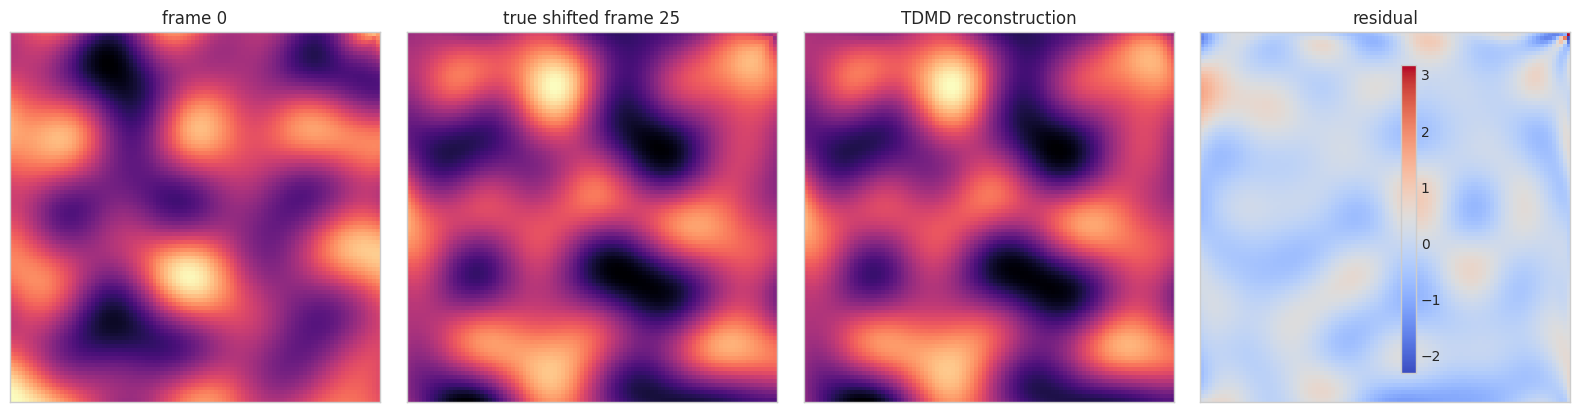

In [3]:
Z, t = make_plasma(nx=96, ny=96, nt=80)
X_minus, X_plus = split_shifted_tensor(Z)
L = FFTTransform()

rank = 20
energy_threshold = 0.995
svd_threshold = 1.0e-8

U_r, S_r, Vh_r = truncated_tsvd(
    X_minus,
    L,
    rank=rank,
    energy_threshold=energy_threshold,
    svd_threshold=svd_threshold,
)
modes, eigen_tensor = tdmd(
    X_minus,
    X_plus,
    L,
    rank=rank,
    energy_threshold=energy_threshold,
    svd_threshold=svd_threshold,
)
X_plus_hat = reconstruct_tdmd_shift(X_minus, modes, eigen_tensor, L)

fit_error = relative_error(X_plus, X_plus_hat)
frame_idx = 24

print(f"sequence shape = {tuple(Z.shape)}")
print(f"truncated t-SVD rank = {S_r.shape[0]}")
print(f"modes shape = {tuple(modes.shape)}")
print(f"eigen tensor shape = {tuple(eigen_tensor.shape)}")
print(f"relative shift-fit error = {fit_error:.4e}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img0 = draw_frame(axes[0], Z[:, :, 0], "frame 0")
img1 = draw_frame(axes[1], X_plus[:, :, frame_idx], f"true shifted frame {frame_idx + 1}")
img2 = draw_frame(axes[2], X_plus_hat[:, :, frame_idx], "TDMD reconstruction")
img3 = draw_frame(axes[3], X_plus[:, :, frame_idx] - X_plus_hat[:, :, frame_idx], "residual", cmap="coolwarm")
fig.colorbar(img3, ax=axes, fraction=0.02, pad=0.02)
plt.tight_layout()
